# LSTM Forex Trading Strategy
### Recreating: Predictive modeling of foreign exchange trading signals using machine learning techniques

**Authors:** Sugarbayar Enkhbayar, Robert Ślepaczuk  
**Journal:** Expert Systems With Applications (2025)

---

## Step 1: Data Loading & Exploration

We'll start by loading the forex data and understanding its structure.

In [15]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-darkgrid')

print("Libraries imported successfully!")

Libraries imported successfully!


In [16]:
# Load forex data
# According to the study, they used 6 major pairs: EURUSD, GBPUSD, USDCHF, USDCAD, AUDUSD, NZDUSD
# We have: EURUSD, GBPUSD, AUDUSD, USDJPY

# Let's start with EURUSD daily data
df = pd.read_csv('data/EURUSD_1day.csv')

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Set date as index
df.set_index('date', inplace=True)

# Display basic info
print(f"Dataset shape: {df.shape}")
print(f"\nDate range: {df.index.min()} to {df.index.max()}")
print(f"\nFirst few rows:")
df.head()

Dataset shape: (6743, 5)

Date range: 2000-01-03 00:00:00 to 2025-11-07 00:00:00

First few rows:


,open,high,low,close,volume
date,,,,,
2000-01-03,1.00741,1.02861,1.00531,1.02451,0
2000-01-04,1.02451,1.03421,1.02181,1.03011,0
2000-01-05,1.03011,1.04041,1.02861,1.03261,0
2000-01-06,1.03261,1.04151,1.02811,1.03301,0
2000-01-07,1.03301,1.03351,1.02561,1.02881,0


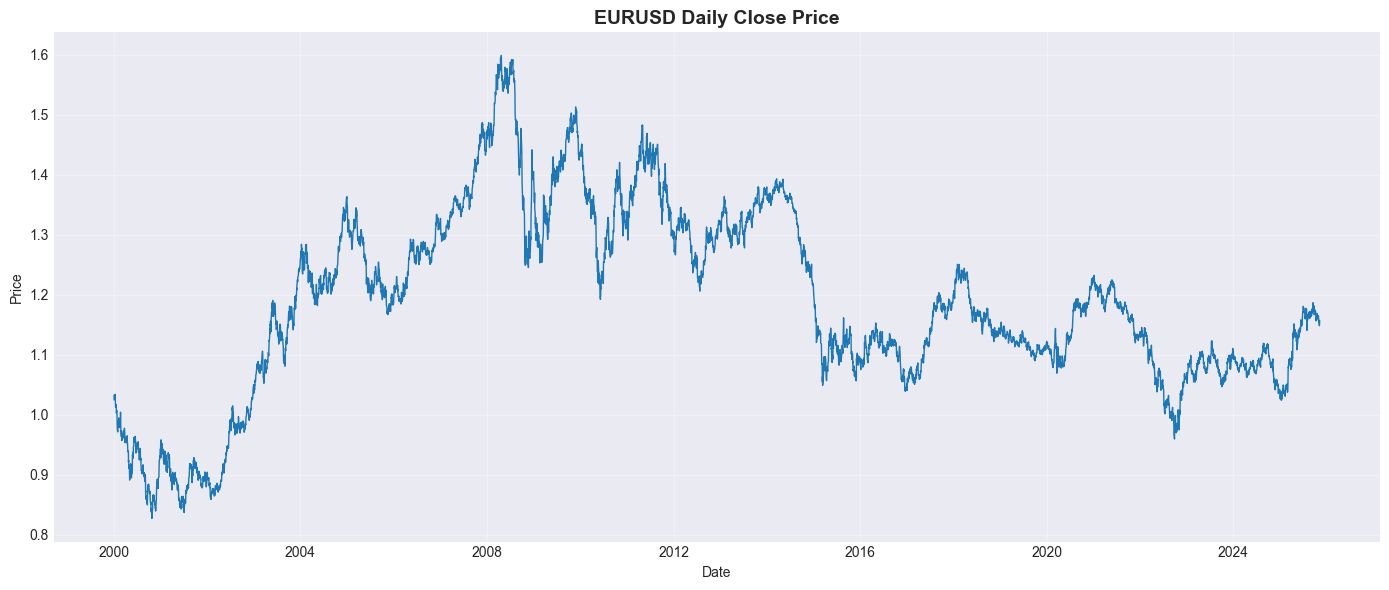

In [17]:
# Visualize the close price over time
plt.figure(figsize=(14, 6))
plt.plot(df.index, df['close'], linewidth=1)
plt.title('EURUSD Daily Close Price', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Price')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [18]:
# Calculate simple returns
df['simple_return'] = df['close'].pct_change()

# Calculate log returns
df['log_return'] = np.log(df['close'] / df['close'].shift(1))

# Display return statistics
print("Return Statistics:")
print(f"\nSimple Return - Mean: {df['simple_return'].mean():.6f}")
print(f"Simple Return - Std: {df['simple_return'].std():.6f}")
print(f"\nLog Return - Mean: {df['log_return'].mean():.6f}")
print(f"Log Return - Std: {df['log_return'].std():.6f}")

Return Statistics:

Simple Return - Mean: 0.000035
Simple Return - Std: 0.005798

Log Return - Mean: 0.000018
Log Return - Std: 0.005797


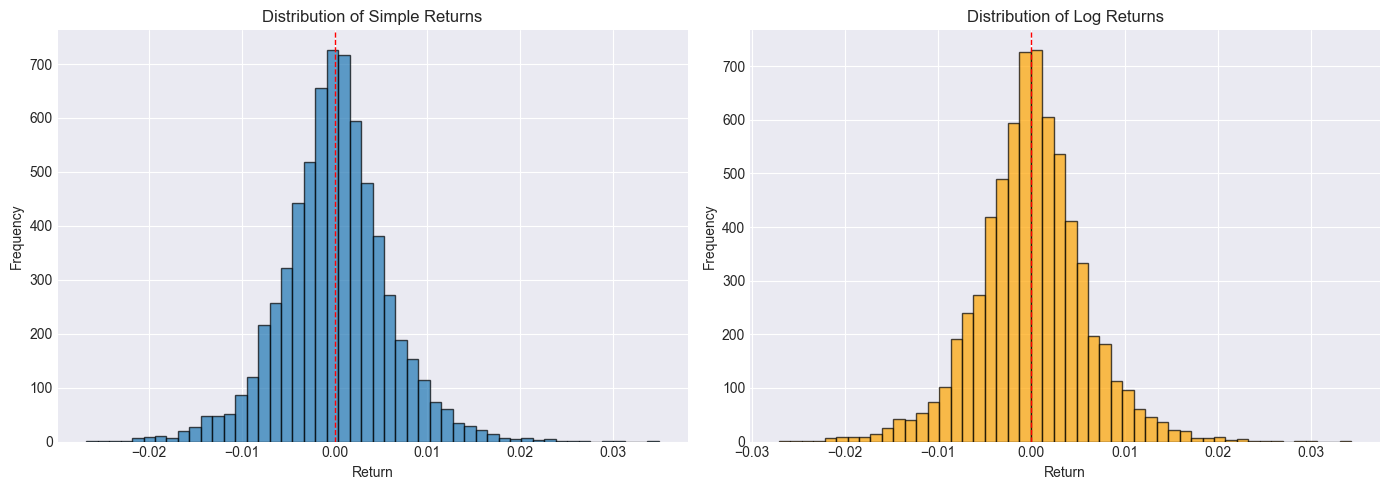

In [19]:
# Visualize return distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Simple returns
axes[0].hist(df['simple_return'].dropna(), bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Distribution of Simple Returns')
axes[0].set_xlabel('Return')
axes[0].set_ylabel('Frequency')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1)

# Log returns
axes[1].hist(df['log_return'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('Distribution of Log Returns')
axes[1].set_xlabel('Return')
axes[1].set_ylabel('Frequency')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.show()

---

## Step 2: Feature Engineering

Implementing all technical and statistical indicators from Table 3 and Section 3.3 of the study.

### Technical Indicators:
- **Momentum**: EMA, MACD, ADX
- **Oscillators**: RSI, Stochastic, CCI, Williams %R
- **Volatility**: Bollinger Bands, ATR

### Statistical Indicators:
- Momentum, Average Price, Range, OHLC

In [20]:
# Create a copy for feature engineering
df_features = df.copy()

print("Starting feature engineering...")
print(f"Initial shape: {df_features.shape}")

# ============================================================================
# 3.3.4 STATISTICAL INDICATORS (Calculate first as they're simple)
# ============================================================================

print("\n[1/4] Calculating Statistical Indicators...")

# Momentum = Open_t - Close_t (Equation 27)
df_features['momentum'] = df_features['open'] - df_features['close']

# Average Price = (Low_t + High_t) / 2 (Equation 28)
df_features['avg_price'] = (df_features['low'] + df_features['high']) / 2

# Range = High_t - Low_t (Equation 29)
df_features['range'] = df_features['high'] - df_features['low']

# OHLC = (Open_t + Close_t + Low_t + High_t) / 4 (Equation 30)
df_features['ohlc'] = (df_features['open'] + df_features['close'] + 
                        df_features['low'] + df_features['high']) / 4

print("   - Momentum, Average Price, Range, OHLC: Done")

# ============================================================================
# 3.3.1 MOMENTUM INDICATORS
# ============================================================================

print("\n[2/4] Calculating Momentum Indicators...")

# Exponential Moving Averages (EMA) - Settings: 10, 20, 50, 100, 200
for period in [10, 20, 50, 100, 200]:
    df_features[f'ema_{period}'] = df_features['close'].ewm(span=period, adjust=False).mean()
    
print("   - EMA (10, 20, 50, 100, 200): Done")

# Moving Average Convergence Divergence (MACD) - Settings: 26, 12, 9
ema_fast = df_features['close'].ewm(span=12, adjust=False).mean()
ema_slow = df_features['close'].ewm(span=26, adjust=False).mean()
df_features['macd'] = ema_fast - ema_slow  # MACD line (Equation 5)
df_features['macd_signal'] = df_features['macd'].ewm(span=9, adjust=False).mean()  # Signal line (Equation 6)
df_features['macd_hist'] = df_features['macd'] - df_features['macd_signal']  # Histogram

print("   - MACD (26, 12, 9): Done")

# Average Directional Index (ADX) - Setting: 14
# Calculate +DM and -DM
high_diff = df_features['high'].diff()
low_diff = -df_features['low'].diff()

plus_dm = high_diff.copy()
plus_dm[high_diff < low_diff] = 0
plus_dm[plus_dm < 0] = 0

minus_dm = low_diff.copy()
minus_dm[low_diff < high_diff] = 0
minus_dm[minus_dm < 0] = 0

# Calculate ATR for ADX (needed for normalization)
tr1 = df_features['high'] - df_features['low']
tr2 = abs(df_features['high'] - df_features['close'].shift(1))
tr3 = abs(df_features['low'] - df_features['close'].shift(1))
tr = pd.concat([tr1, tr2, tr3], axis=1).max(axis=1)
atr_14 = tr.rolling(window=14).mean()

# Smooth +DM and -DM
plus_dm_smooth = plus_dm.rolling(window=14).mean()
minus_dm_smooth = minus_dm.rolling(window=14).mean()

# Calculate +DI and -DI (Equations 7, 8)
plus_di = 100 * (plus_dm_smooth / atr_14)
minus_di = 100 * (minus_dm_smooth / atr_14)

# Calculate DX (Equation 9)
dx = 100 * abs(plus_di - minus_di) / (plus_di + minus_di)

# Calculate ADX (Equation 10)
df_features['adx'] = dx.rolling(window=14).mean()
df_features['plus_di'] = plus_di
df_features['minus_di'] = minus_di

print("   - ADX (14): Done")

# ============================================================================
# 3.3.2 OSCILLATOR INDICATORS
# ============================================================================

print("\n[3/4] Calculating Oscillator Indicators...")

# Relative Strength Index (RSI) - Setting: 14
delta = df_features['close'].diff()
gain = delta.copy()
loss = delta.copy()
gain[gain < 0] = 0
loss[loss > 0] = 0
loss = abs(loss)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss
df_features['rsi'] = 100 - (100 / (1 + rs))  # Equation 14

print("   - RSI (14): Done")

# Stochastic Oscillator - Settings: 14, 3
low_14 = df_features['low'].rolling(window=14).min()
high_14 = df_features['high'].rolling(window=14).max()

df_features['stoch_k'] = 100 * ((df_features['close'] - low_14) / (high_14 - low_14))  # Equation 15
df_features['stoch_d'] = df_features['stoch_k'].rolling(window=3).mean()  # Equation 16

print("   - Stochastic Oscillator (14, 3): Done")

# Commodity Channel Index (CCI) - Settings: 20, 0.015
tp = (df_features['high'] + df_features['low'] + df_features['close']) / 3  # Typical Price (Equation 17)
ma_tp = tp.rolling(window=20).mean()  # Moving Average (Equation 18)
md = abs(tp - ma_tp).rolling(window=20).mean()  # Mean Deviation (Equation 19)
df_features['cci'] = (tp - ma_tp) / (0.015 * md)  # Equation 20

print("   - CCI (20, 0.015): Done")

# Williams %R - Setting: 14
high_14 = df_features['high'].rolling(window=14).max()
low_14 = df_features['low'].rolling(window=14).min()
df_features['williams_r'] = -100 * ((high_14 - df_features['close']) / (high_14 - low_14))  # Equation 21

print("   - Williams %R (14): Done")

# ============================================================================
# 3.3.3 VOLATILITY INDICATORS
# ============================================================================

print("\n[4/4] Calculating Volatility Indicators...")

# Bollinger Bands - Settings: 20, 2
sma_20 = df_features['close'].rolling(window=20).mean()
std_20 = df_features['close'].rolling(window=20).std()

df_features['bb_middle'] = sma_20  # Equation 22
df_features['bb_upper'] = sma_20 + (2 * std_20)  # Equation 23
df_features['bb_lower'] = sma_20 - (2 * std_20)  # Equation 24
df_features['bb_width'] = df_features['bb_upper'] - df_features['bb_lower']
df_features['bb_position'] = (df_features['close'] - df_features['bb_lower']) / df_features['bb_width']

print("   - Bollinger Bands (20, 2): Done")

# Average True Range (ATR) - Setting: 14
df_features['atr'] = atr_14  # Equation 26

print("   - ATR (14): Done")

# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "="*60)
print("Feature Engineering Complete!")
print("="*60)
print(f"\nFinal shape: {df_features.shape}")
print(f"Total features created: {df_features.shape[1] - df.shape[1]}")
print(f"\nFeature categories:")
print(f"  - Original columns: {df.shape[1]}")
print(f"  - Statistical indicators: 4")
print(f"  - EMAs: 5")
print(f"  - MACD: 3")
print(f"  - ADX: 3")
print(f"  - RSI: 1")
print(f"  - Stochastic: 2")
print(f"  - CCI: 1")
print(f"  - Williams %R: 1")
print(f"  - Bollinger Bands: 5")
print(f"  - ATR: 1")

# Display first few rows with new features
print("\nSample of features (first 5 rows, last 10 columns):")
print(df_features.iloc[:5, -10:])

Starting feature engineering...
Initial shape: (6743, 7)

[1/4] Calculating Statistical Indicators...
   - Momentum, Average Price, Range, OHLC: Done

[2/4] Calculating Momentum Indicators...
   - EMA (10, 20, 50, 100, 200): Done
   - MACD (26, 12, 9): Done
   - ADX (14): Done

[3/4] Calculating Oscillator Indicators...
   - RSI (14): Done
   - Stochastic Oscillator (14, 3): Done
   - CCI (20, 0.015): Done
   - Williams %R (14): Done

[4/4] Calculating Volatility Indicators...
   - Bollinger Bands (20, 2): Done
   - ATR (14): Done

Feature Engineering Complete!

Final shape: (6743, 33)
Total features created: 26

Feature categories:
  - Original columns: 7
  - Statistical indicators: 4
  - EMAs: 5
  - MACD: 3
  - ADX: 3
  - RSI: 1
  - Stochastic: 2
  - CCI: 1
  - Williams %R: 1
  - Bollinger Bands: 5
  - ATR: 1

Sample of features (first 5 rows, last 10 columns):
            stoch_k  stoch_d  cci  williams_r  bb_middle  bb_upper  bb_lower  \
date                                        

In [21]:
# Check for missing values
print("Missing values per feature:")
missing = df_features.isnull().sum()
print(missing[missing > 0].sort_values(ascending=False))

print(f"\nTotal rows with any missing values: {df_features.isnull().any(axis=1).sum()}")
print(f"Percentage of rows with missing values: {df_features.isnull().any(axis=1).sum() / len(df_features) * 100:.2f}%")

Missing values per feature:
cci              38
adx              27
bb_width         19
bb_upper         19
bb_lower         19
bb_position      19
bb_middle        19
stoch_d          15
plus_di          14
minus_di         14
rsi              14
stoch_k          13
williams_r       13
atr              13
log_return        1
simple_return     1
dtype: int64

Total rows with any missing values: 38
Percentage of rows with missing values: 0.56%


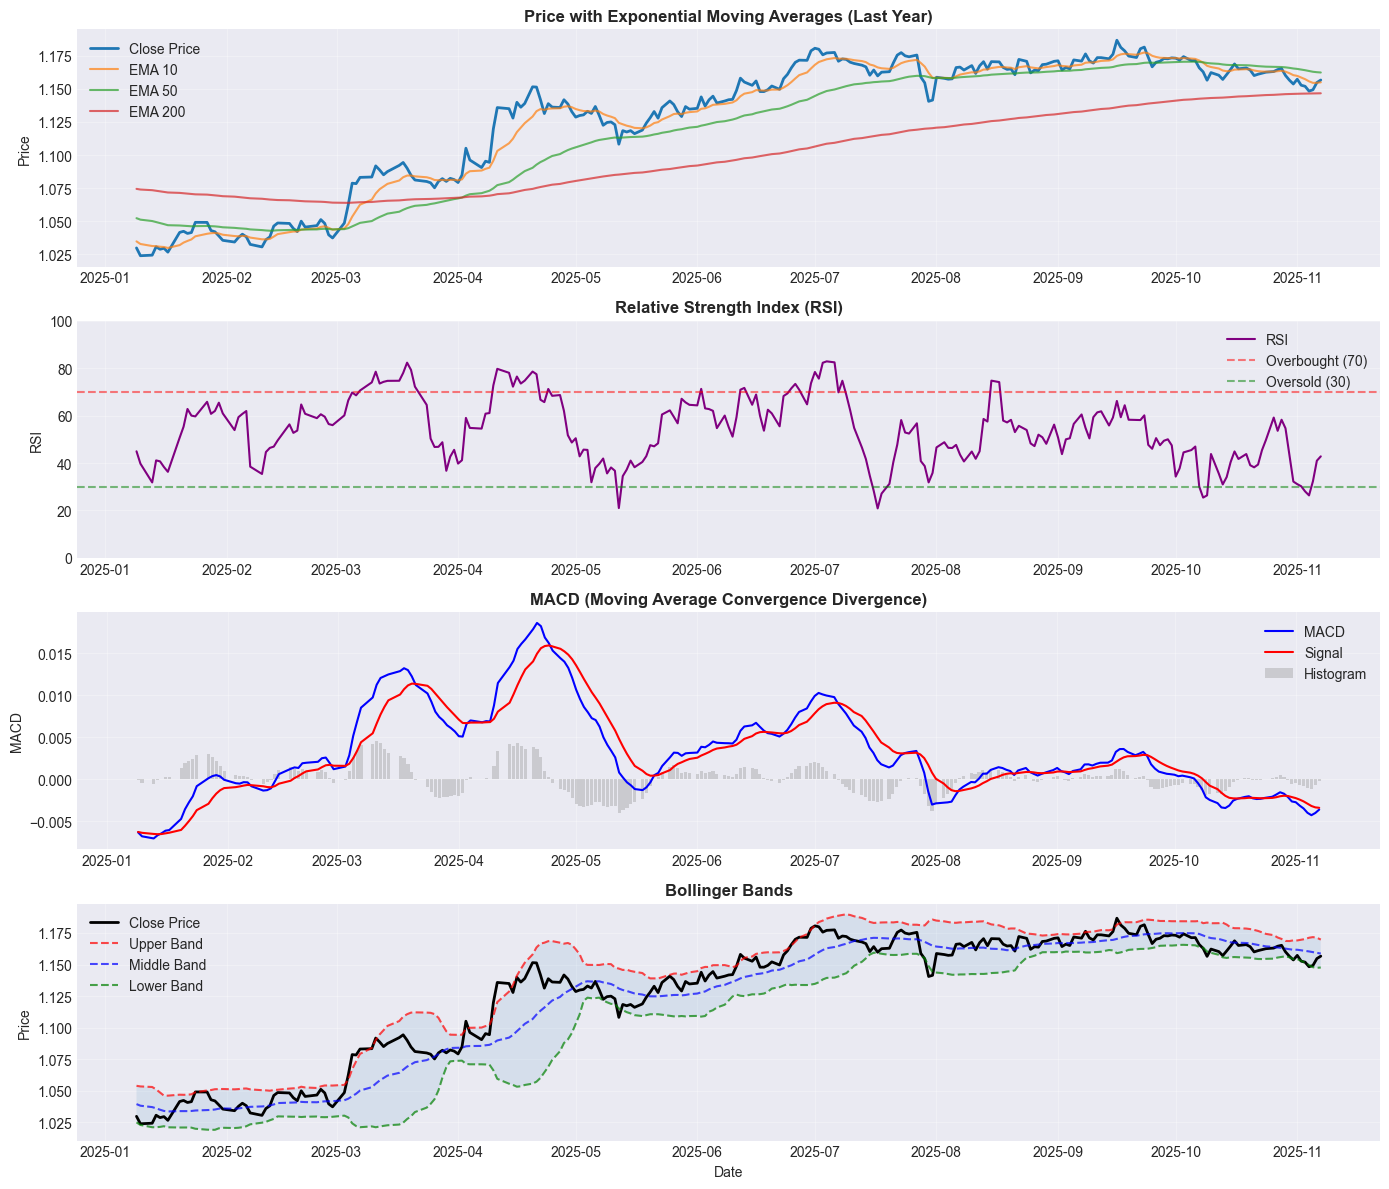

Technical indicators visualization complete!


In [22]:
# Visualize some key technical indicators
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

# Plot 1: Price with EMAs
ax1 = axes[0]
ax1.plot(df_features.index[-252:], df_features['close'].iloc[-252:], label='Close Price', linewidth=2)
ax1.plot(df_features.index[-252:], df_features['ema_10'].iloc[-252:], label='EMA 10', alpha=0.7)
ax1.plot(df_features.index[-252:], df_features['ema_50'].iloc[-252:], label='EMA 50', alpha=0.7)
ax1.plot(df_features.index[-252:], df_features['ema_200'].iloc[-252:], label='EMA 200', alpha=0.7)
ax1.set_title('Price with Exponential Moving Averages (Last Year)', fontweight='bold')
ax1.set_ylabel('Price')
ax1.legend(loc='best')
ax1.grid(True, alpha=0.3)

# Plot 2: RSI
ax2 = axes[1]
ax2.plot(df_features.index[-252:], df_features['rsi'].iloc[-252:], label='RSI', color='purple')
ax2.axhline(y=70, color='r', linestyle='--', alpha=0.5, label='Overbought (70)')
ax2.axhline(y=30, color='g', linestyle='--', alpha=0.5, label='Oversold (30)')
ax2.set_title('Relative Strength Index (RSI)', fontweight='bold')
ax2.set_ylabel('RSI')
ax2.set_ylim(0, 100)
ax2.legend(loc='best')
ax2.grid(True, alpha=0.3)

# Plot 3: MACD
ax3 = axes[2]
ax3.plot(df_features.index[-252:], df_features['macd'].iloc[-252:], label='MACD', color='blue')
ax3.plot(df_features.index[-252:], df_features['macd_signal'].iloc[-252:], label='Signal', color='red')
ax3.bar(df_features.index[-252:], df_features['macd_hist'].iloc[-252:], label='Histogram', alpha=0.3, color='gray')
ax3.set_title('MACD (Moving Average Convergence Divergence)', fontweight='bold')
ax3.set_ylabel('MACD')
ax3.legend(loc='best')
ax3.grid(True, alpha=0.3)

# Plot 4: Bollinger Bands
ax4 = axes[3]
ax4.plot(df_features.index[-252:], df_features['close'].iloc[-252:], label='Close Price', linewidth=2, color='black')
ax4.plot(df_features.index[-252:], df_features['bb_upper'].iloc[-252:], label='Upper Band', linestyle='--', color='red', alpha=0.7)
ax4.plot(df_features.index[-252:], df_features['bb_middle'].iloc[-252:], label='Middle Band', linestyle='--', color='blue', alpha=0.7)
ax4.plot(df_features.index[-252:], df_features['bb_lower'].iloc[-252:], label='Lower Band', linestyle='--', color='green', alpha=0.7)
ax4.fill_between(df_features.index[-252:], df_features['bb_lower'].iloc[-252:], df_features['bb_upper'].iloc[-252:], alpha=0.1)
ax4.set_title('Bollinger Bands', fontweight='bold')
ax4.set_ylabel('Price')
ax4.set_xlabel('Date')
ax4.legend(loc='best')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Technical indicators visualization complete!")

In [23]:
# Save the features dataframe for later use
df_features.to_csv('data/EURUSD_1day_with_features.csv')
print("Features saved to 'data/EURUSD_1day_with_features.csv'")

# Display summary statistics for all features
print("\nSummary statistics for technical indicators:")
feature_cols = [col for col in df_features.columns if col not in df.columns]
print(df_features[feature_cols].describe().T)

Features saved to 'data/EURUSD_1day_with_features.csv'

Summary statistics for technical indicators:
              count       mean        std         min        25%        50%  \
momentum     6743.0  -0.000049   0.006938   -0.045450  -0.003830  -0.000070   
avg_price    6743.0   1.186743   0.154145    0.827810   1.088763   1.175325   
range        6743.0   0.010243   0.005691    0.000010   0.006380   0.008920   
ohlc         6743.0   1.186723   0.154156    0.828310   1.088621   1.175340   
ema_10       6743.0   1.186640   0.153869    0.841033   1.088339   1.174838   
ema_20       6743.0   1.186539   0.153534    0.849187   1.087994   1.174645   
ema_50       6743.0   1.186226   0.152484    0.859478   1.089449   1.173191   
ema_100      6743.0   1.185727   0.150660    0.873158   1.089366   1.170252   
ema_200      6743.0   1.184925   0.147263    0.885310   1.087155   1.169996   
macd         6743.0   0.000143   0.007961   -0.041412  -0.004373   0.000017   
macd_signal  6743.0   0.000145

In [26]:
df_features.tail()

,open,high,low,close,volume,simple_return,log_return,momentum,avg_price,range,ohlc,ema_10,ema_20,ema_50,ema_100,ema_200,macd,macd_signal,macd_hist,adx,plus_di,minus_di,rsi,stoch_k,stoch_d,cci,williams_r,bb_middle,bb_upper,bb_lower,bb_width,bb_position,atr
date,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2025-11-03,1.15317,1.15414,1.15052,1.15190,122622,-0.000685,-0.000686,0.00127,1.152330,0.00362,1.152432,1.157273,1.160217,1.164038,1.161412,1.146381,-0.003473,-0.002629,-0.000844,25.445490,6.757532,28.737446,28.036790,8.098592,12.038266,-143.206705,-91.901408,1.160823,1.170195,1.151450,0.018745,0.023994,0.004979
2025-11-04,1.15200,1.15337,1.14732,1.14826,118115,-0.003160,-0.003165,0.00374,1.150345,0.00605,1.150237,1.155634,1.159078,1.163419,1.161152,1.146400,-0.003993,-0.002902,-0.001090,28.113522,6.540758,31.259547,26.348733,4.805726,5.439755,-176.867408,-95.194274,1.160382,1.171212,1.149552,0.021659,-0.059665,0.005144
2025-11-05,1.14834,1.14981,1.14686,1.14925,115552,0.000862,0.000862,-0.00091,1.148335,0.00295,1.148565,1.154474,1.158142,1.162864,1.160916,1.146428,-0.004275,-0.003177,-0.001098,30.754596,6.806358,27.341040,32.324893,11.938062,8.280793,-180.941702,-88.061938,1.159805,1.171719,1.147891,0.023827,0.057019,0.004943
2025-11-06,1.14913,1.15523,1.14907,1.15471,116104,0.004751,0.004740,-0.00558,1.152150,0.00616,1.152035,1.154517,1.157816,1.162544,1.160793,1.146511,-0.004012,-0.003344,-0.000668,30.557037,14.307910,23.799435,40.980786,39.210789,18.651526,-100.942573,-60.789211,1.159307,1.171198,1.147417,0.023782,0.306681,0.005057
2025-11-07,1.15450,1.15911,1.15296,1.15664,112545,0.001671,0.001670,-0.00214,1.156035,0.00615,1.155803,1.154903,1.157704,1.162312,1.160711,1.146612,-0.003606,-0.003396,-0.000210,29.306234,19.069008,22.934531,42.817449,48.851149,33.333333,-41.073809,-51.148851,1.158701,1.169769,1.147633,0.022135,0.406891,0.005248
